In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq

In [3]:
audio_path = librosa.ex("trumpet")
y, sr = librosa.load(audio_path, sr=None)

print("Sampling Rate:", sr)
print("Duration:", len(y)/sr)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sampling Rate: 22050
Duration: 5.333378684807256


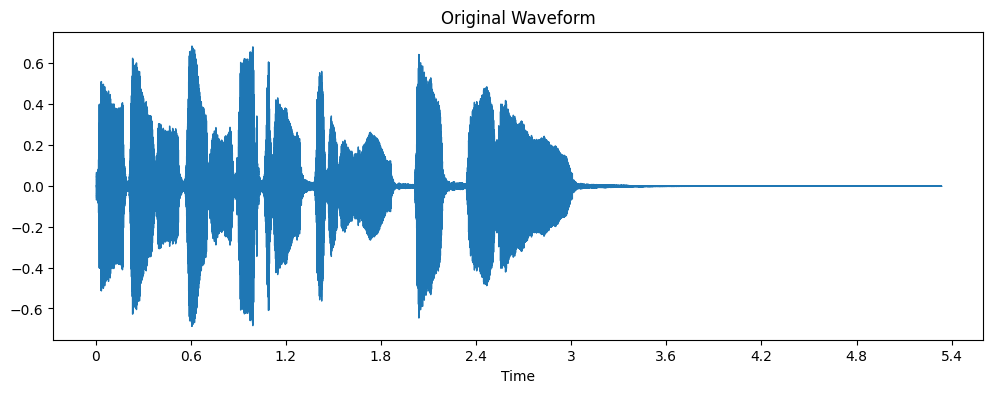

In [4]:
plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Original Waveform")
plt.show()

In [5]:
target_sr = 16000
y_resampled = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

In [6]:
y_norm = librosa.util.normalize(y_resampled)

In [7]:
y_trimmed, index = librosa.effects.trim(y_norm)

print(index)

[    0 61440]


In [8]:
processed = y_trimmed
sr = target_sr

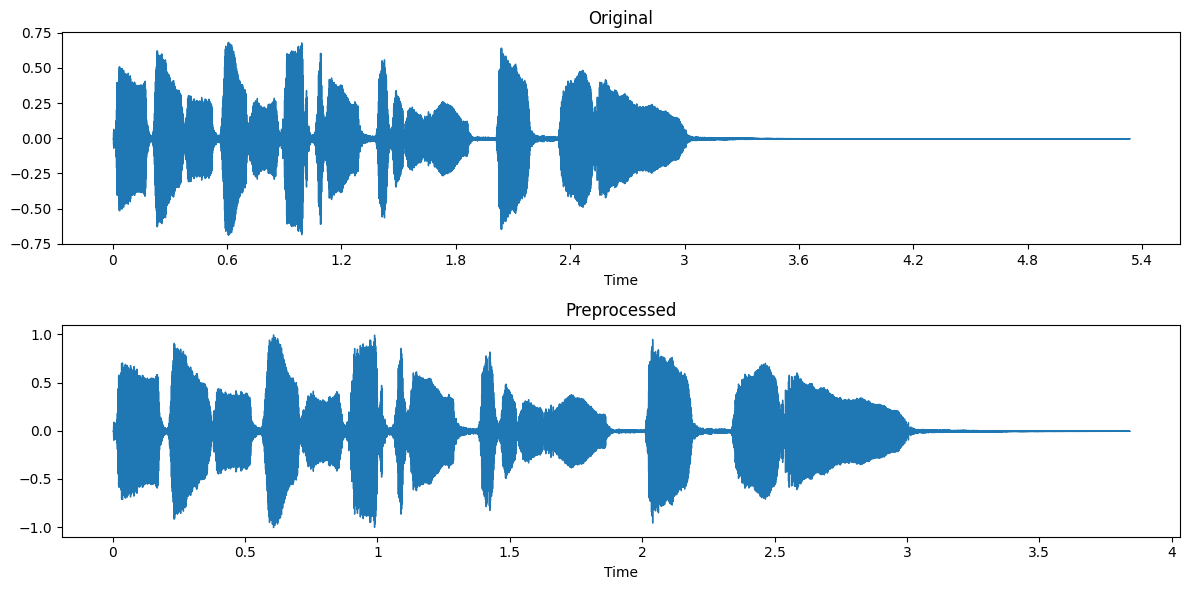

In [10]:
fig, ax = plt.subplots(2,1, figsize=(12,6))

librosa.display.waveshow(y, sr=22050, ax=ax[0])
ax[0].set_title("Original")

librosa.display.waveshow(processed, sr=sr, ax=ax[1])
ax[1].set_title("Preprocessed")

plt.tight_layout()
plt.show()

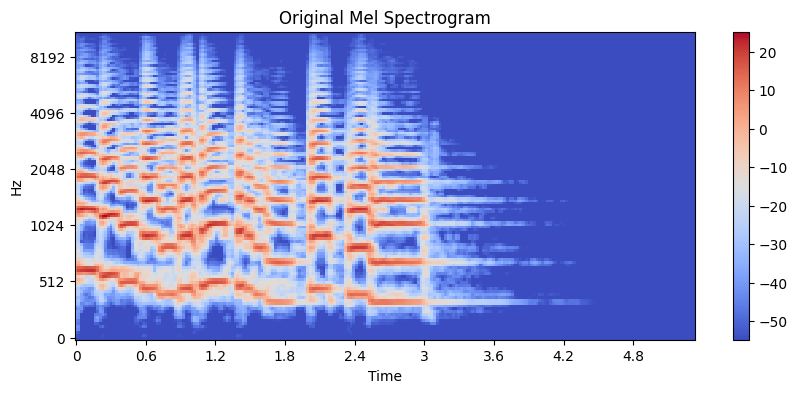

In [ ]:
mel = librosa.feature.melspectrogram(y=y, sr=22050)

plt.figure(figsize=(10,4))
librosa.display.specshow(librosa.power_to_db(mel),
                         sr=22050,
                         x_axis='time',
                         y_axis='mel')

plt.colorbar()
plt.title("Original Mel Spectrogram")
plt.show()

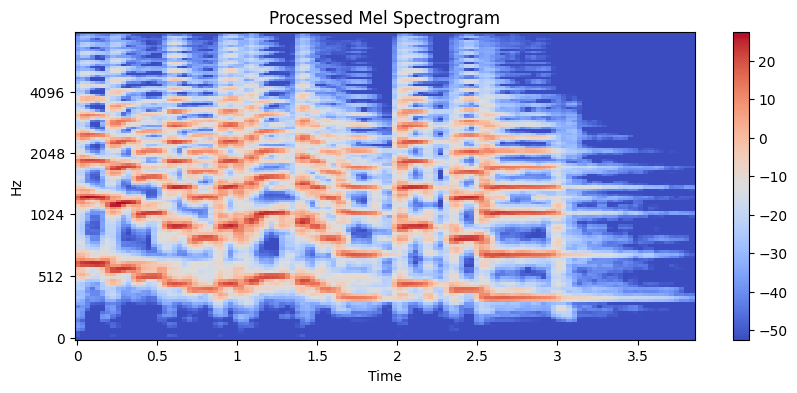

In [ ]:
mel = librosa.feature.melspectrogram(y=processed,
                                     sr=sr)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    librosa.power_to_db(mel),
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()
plt.title("Processed Mel Spectrogram")
plt.show()

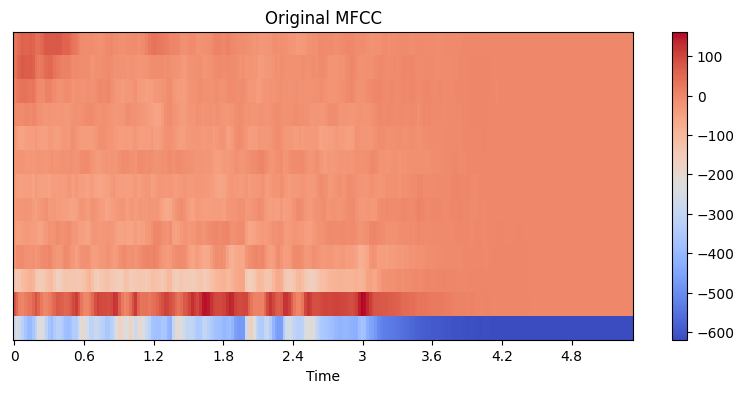

In [ ]:
mfcc = librosa.feature.mfcc(y=y, sr=22050, n_mfcc=13)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("Original MFCC")
plt.show()

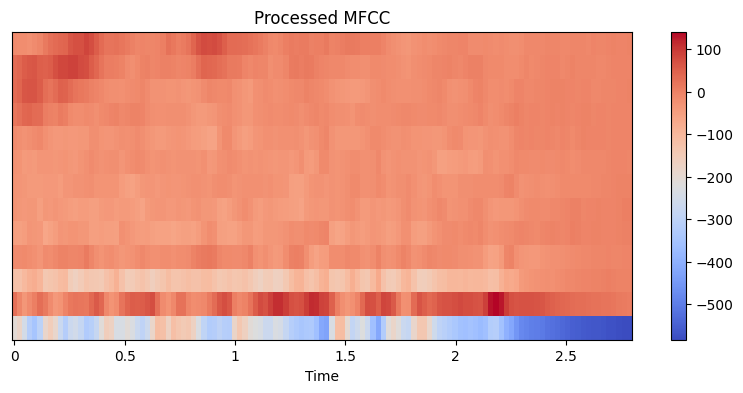

In [ ]:
mfcc = librosa.feature.mfcc(
    y=processed,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("Processed MFCC")
plt.show()

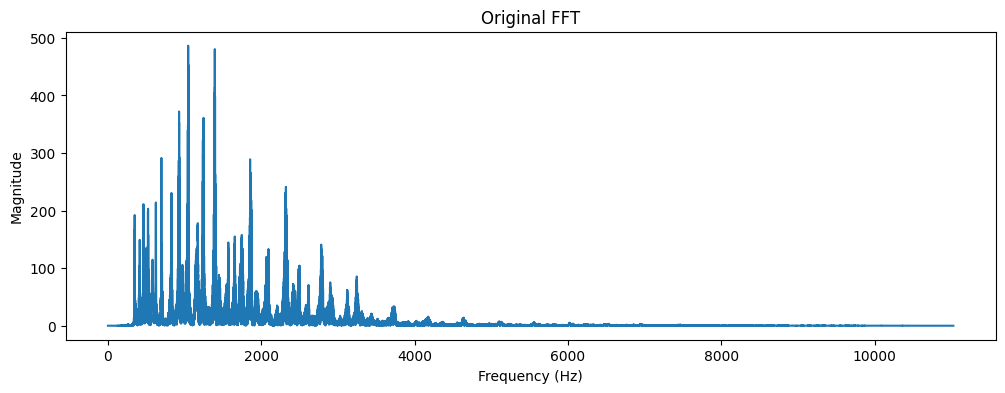

In [ ]:
N = len(y)

yf = fft(y)

xf = fftfreq(N, 1/22050)

plt.figure(figsize=(12,4))

plt.plot(xf[:N//2], np.abs(yf[:N//2]))

plt.title("Original FFT")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.show()

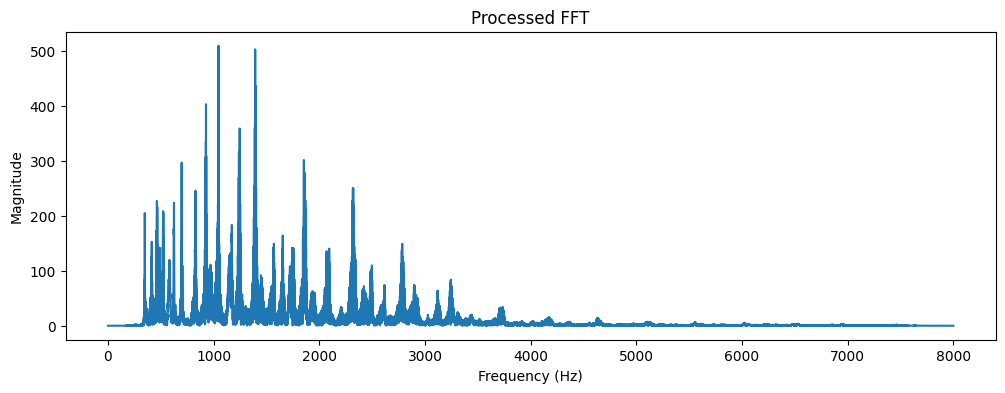

In [ ]:
N = len(processed)

yf = fft(processed)

xf = fftfreq(N, 1/sr)

plt.figure(figsize=(12,4))

plt.plot(xf[:N//2], np.abs(yf[:N//2]))

plt.title("Processed FFT")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.show()

In [ ]:
print("Original Sample Rate :",22050)
print("Processed Sample Rate:",sr)

print("Original Samples :",len(y))
print("Processed Samples:",len(processed))

Original Sample Rate : 22050
Processed Sample Rate: 16000
Original Samples : 117601
Processed Samples: 61440
